# U1｜機器學習基礎與工作流程

> 單元一　|　scikit-learn 為主軸　|

**單元目標**：建立一套可重用的建模工作流程。完成本單元後，學生能用 scikit-learn 完成
`split → 訓練 → 交叉驗證 → 評估` 的完整迴圈，並理解過擬合與資料洩漏的成因。

**學習目標**
1. 說明監督式學習的迴歸與分類任務差異，並複述 ML 七步驟工作流程。
2. 使用 sklearn 的 `fit / predict / score` 三件套訓練第一個模型。
3. 用多項式複雜度示範過擬合，解釋 bias-variance 權衡。
4. 用 `cross_val_score` 取代單次切分，穩健評估模型。
5. 用 `Pipeline` 串接特徵縮放與模型，避免資料洩漏，並建立通用建模模板。

---

## Part 0 | 環境與資料準備

In [65]:
import numpy as np # 矩陣運算的核心套件
import pandas as pd # Python界的Excel
import matplotlib.pyplot as plt # 專門用來處理畫畫的問題
import sklearn # 很重要機器學習套件
print(f'Scilit-Learn: {sklearn.__version__}')

np.random.seed(42) # 固定亂數種子，為了讓結果重現


Scilit-Learn: 1.9.0


**載入第一個資料集：California Housing（加州房價）**

這是一個迴歸資料集：用區域的人口統計特徵預測房價中位數。
特徵直覺、量綱差異大（收入是個位數、人口是上千），很適合示範後面的「特徵縮放」。

In [66]:
# 從sklearn模組內建的dataset取出加州房價的資料集
from sklearn.datasets import fetch_california_housing

# 載入加州房價的資料集
data = fetch_california_housing(as_frame=True)
data = data.frame
data


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


## Part 1｜機器學習導論與工作流程

### 什麼是機器學習
傳統程式是「人寫規則」；機器學習是「從資料中自動學出規則」。給定大量
（輸入 X，答案 y）的例子，模型自己找出 X→y 的對應關係。

三大類型：
- **監督式學習**（本課程主軸）：資料有正確答案 y，學 X→y。
- **非監督式學習**（U5）：資料沒有 y，找資料的結構（分群、降維）。
- **強化學習**：透過與環境互動、獎勵訊號學習（本課程不涵蓋）。

### 監督式學習的兩大任務

| 任務 | 目標 y 型態 | 例子 | 評估指標 |
|------|------------|------|----------|
| **迴歸** | 連續數值 | 房價、報酬率、波動度 | R²、RMSE、MAE |
| **分類** | 離散標籤 | 漲/跌、違約/正常、詐欺/正常 | accuracy、F1、AUC |

本單元以**迴歸**（房價）示範完整流程；分類留待 U3 深入。

### ML 標準工作流程

1. **定義問題與目標變數** — 釐清要預測什麼、是迴歸還分類
2. **資料準備與切分** — 切出訓練集 / 測試集
3. **特徵工程** — 縮放、編碼、建立衍生特徵
4. **選模型與訓練** — `model.fit(X_train, y_train)`
5. **交叉驗證與調參** — 在訓練集內做 CV，選超參數
6. **在測試集評估** — 只在最後做一次，模擬真實表現
7. **部署 / 解釋** — 上線、解讀模型

> ⚠️ **黃金法則**：步驟 5 之前**絕對不能碰測試集**。
> 測試集一旦在訓練/調參過程中被「看過」，評估結果就會過度樂觀。

**資料探索：先看分布與相關性**

In [67]:
# describe() 用來快速看每個欄位的分布：筆數、平均、標準差、最小/最大、四分位數
# 解讀本例結果：
#   count 都是20640 → 沒有缺失值(每欄資料都完整)
#   各欄尺度差很大：Population 上千上萬，MedInc 只有個位數 → 之後距離型模型(KNN)要先標準化
#   AveRooms 平均5.4但max=141、AveOccup 平均3但max=1243 → 有明顯極端值(outlier)
#   MedHouseVal 最大剛好=5.00 → 房價被截斷在5(超過5都記成5)，這是這份資料的已知特性
data.describe()
# 計算皮爾森相關係數，去看出各個特徵跟房價的相關程度
# 係數範圍 -1~+1：正=一起變大、負=反向；絕對值越接近1關係越強、越接近0越沒關係
#   注意：負很大(接近-1)一樣是「關係很強」，只是方向相反(一個變大另一個明顯變小)
#         強弱只看絕對值，跟正負號無關；-0.9 和 +0.9 一樣強
# 解讀本例結果：
#   MedInc(收入) 0.69 → 跟房價關係最強，收入越高房價越高
#   AveRooms、HouseAge 約0.1 → 有一點點正相關但很弱
#   其餘欄位接近0(-0.02~-0.14) → 跟房價幾乎沒有線性關係
# 提醒：相關係數只看「線性」關係，且「相關 ≠ 因果」
data.corr()['MedHouseVal'].sort_values(ascending=False)

MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64

## Part 2｜sklearn API 與第一個模型

### Estimator API：三件套
scikit-learn 所有模型共用同一組介面，學會一次、處處適用：

| 方法 | 作用 |
|------|------|
| `model.fit(X, y)` | 用訓練資料**學習** |
| `model.predict(X)` | 對新資料**預測** |
| `model.score(X, y)` | **評分**（迴歸回傳 R²、分類回傳 accuracy） |

換任何模型，通常只需改「建立模型」那一行。

**步驟 1：切出特徵 X 與目標 y，再分割訓練 / 測試集**

In [68]:
from sklearn.model_selection import train_test_split

X = data.drop(columns='MedHouseVal') # 特徵X: 移除預測目標後所剩下的8個欄位
X
y = data['MedHouseVal'] # 預測目標y:要預測的房價中位數
y

# 將資料切成兩份，分別是訓練集和測試集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'訓練集: {X_train.shape}, 測試集: {X_test.shape}')
print(f'訓練集: {y_train.shape}, 測試集: {y_test.shape}')

訓練集: (16512, 8), 測試集: (4128, 8)
訓練集: (16512,), 測試集: (4128,)


**步驟 2：訓練第一個模型:線性迴歸**

In [69]:
# 匯入線性迴歸模型
from sklearn.linear_model import LinearRegression

model = LinearRegression() # 建立模型物件
model.fit(X_train, y_train) # 開始訓練模型
print(f'訓練集R2: {model.score(X_train, y_train):.4f}') # 進行模型的評分
print(f'測試集R2: {model.score(X_test, y_test):.4f}') # 進行模型的評分
# R2(決定係數)：模型能解釋房價變化的比例，範圍最高1、越接近1越好
# 解讀本例結果：
#   訓練集0.61、測試集0.58 → 大約能解釋六成的房價變化，普通但還算合理
#   兩者很接近 → 沒有明顯過擬合(模型在沒看過的資料上表現差不多)

訓練集R2: 0.6126
測試集R2: 0.5758


**步驟 3：檢視係數**

In [70]:
# model.coef_ 就是每個特徵的「係數」
# 白話說：這個特徵每增加 1，房價預測就跟著加上這個數字
# 正數代表把房價往上推、負數往下拉，數字絕對值越大代表影響越大
# 正負號=方向、絕對值=力道，兩者要分開看：
#   +0.45 → 強力往上推；-0.43 → 強力往下拉(力道跟+0.45差不多，只是反方向)
#   -0.01 → 雖然是負的但接近0，幾乎沒影響
#   注意：負很大(接近-1)一樣是「關係很強」，只是方向相反(一個變大另一個明顯變小)
#         強弱只看絕對值，跟正負號無關；-0.9 和 +0.9 一樣強
# 解讀本例結果：
#   MedInc(收入) 0.45 → 收入越高房價越高，跟前面相關係數的結論一致
#   Latitude -0.42、Longitude -0.43 → 地理位置：越往北/往西房價越低
#   Population 幾乎是0 → 對房價幾乎沒影響
# 提醒：各特徵的「單位/尺度」不同(例如收入 vs 房間數)，
#       所以係數大小不能直接拿來比誰重要，要先做標準化才公平
pd.Series(model.coef_, index=X_train.columns).sort_values(ascending=False)

AveBedrms     0.783145
MedInc        0.448675
HouseAge      0.009724
Population   -0.000002
AveOccup     -0.003526
AveRooms     -0.123323
Latitude     -0.419792
Longitude    -0.433708
dtype: float64

#### 練習題
把模型改成`KNeighborsRegressor`(K=5)重跑一次後，比較R2，需要改幾行?




In [71]:
# 從sklearn模組內建的dataset取出加州房價的資料集
from sklearn.datasets import fetch_california_housing

# 載入加州房價的資料集
data = fetch_california_housing(as_frame=True)
df = data.frame

# 匯入資料切分的工具
from sklearn.model_selection import train_test_split

X = df.drop(columns='MedHouseVal') # 特徵X: 移除預測目標後所剩下的8個欄位
y = df['MedHouseVal'] # 預測目標y:要預測的房價中位數

# 將資料切成兩份，分別是訓練集和測試集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 匯入KNeighbors
from sklearn.neighbors import KNeighborsRegressor

model = KNeighborsRegressor() # 建立模型物件
model.fit(X_train, y_train) # 開始訓練模型

y_pred = model.predict(X_test)
y_pred

from sklearn.metrics import mean_squared_error, r2_score
print(f'測試集MSE: {mean_squared_error(y_test, y_pred):.4f}')
print(f'測試集R2: {r2_score(y_test, y_pred):.4f}')
print(f'測試集R2: {model.score(X_test, y_test):.4f}') # 進行模型的評分

# 解讀本例結果(對照上面的線性迴歸)：
#   線性迴歸 測試集R2約0.58，這裡KNN只有0.15、MSE也更大 → KNN在這份資料上表現差很多
#   原因：KNN是用「距離」找鄰居，但各特徵尺度差很大(收入 vs 人口)，
#         尺度大的欄位會主宰距離計算 → 之後會用「標準化」來改善(見下面的StandardScaler)

測試集MSE: 1.1187
測試集R2: 0.1463
測試集R2: 0.1463


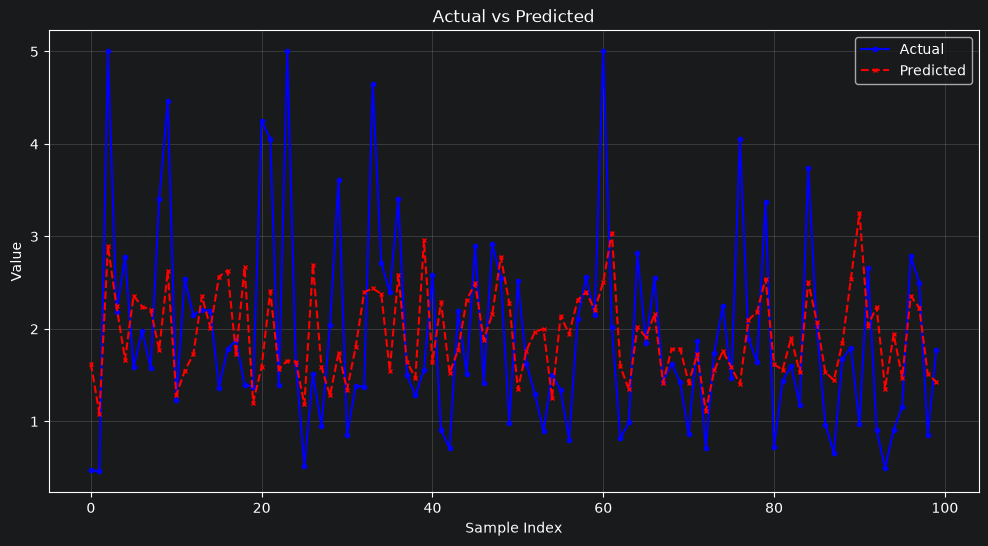

In [72]:
# 因為資料太過龐大，所以我們只取前100筆資料出來畫畫
y_test_part = y_test[:100]
y_pred_part = y_pred[:100]

plt.figure(figsize=(12, 6)) # 設定圖片的大小，這個是寬12高6
# 畫第一條線，真實答案的線，
plt.plot(range(len(y_test_part)), y_test_part, label='Actual', color='blue', marker='o',
         markersize=3)
# 畫第二條線。預測答案的線
plt.plot(range(len(y_pred_part)), y_pred_part, label='Predicted', color='red', marker='x',
         linestyle='--', markersize=3)
plt.xlabel('Sample Index') # 設定X軸
plt.ylabel('Value') # 設定y軸
plt.title('Actual vs Predicted') # 設定圖片的名稱
plt.legend() # 顯示圖例
plt.grid(True, alpha=0.3) # 顯示圖片內的網格，alpha是設定透明度
plt.show() # 顯示圖片

# ── 這張圖怎麼看 ──────────────────────────────
# 藍線Actual=真實房價、紅虛線Predicted=模型預測；X軸是樣本編號、Y軸是房價
# 核心：兩條線貼得越近代表預測越準；差很開就是預測錯(紅在藍上方=高估、下方=低估)
# 本例畫的是上一格未標準化的KNN(R2只有0.15)，所以會看到：
#   兩條線常對不上、藍線很高(接近5)時紅線追不上去 → 對高價房普遍低估
#   紅線比較平滑起伏小 → 模型傾向預測中間值、不敢給極端值
# 用途：R2/MSE只是一個總分，這張圖能用眼睛看出每筆是高估還是低估
#       等之後做完標準化再畫一次，紅線會明顯更貼合藍線，就能看見改善


---

Part 2 我們訓練了模型，並用「一次 train/test 切分」加上 R² 來評分。但這帶出兩個問題：
- **模型的複雜度**該怎麼拿捏？太簡單會**欠擬合**、太複雜會**過擬合**光看訓練分數看不出來。
- 只切一次就決定好壞，會不會**剛好切到好運/壞運**的那一份？

Part 3 就用這兩個問題當主軸：先用合成資料「看見」過擬合，再用**交叉驗證**讓評估更穩。


## Part 3｜過擬合、Bias-Variance 與交叉驗證

### 過擬合 vs 欠擬合
- **欠擬合**：模型太簡單，訓練集與測試集表現都差。
- **過擬合**：模型太複雜，把訓練資料的雜訊也背了起來，
  **訓練分數很高，但測試分數掉下來**。

為了看清楚，這裡用一組**合成的一維資料**（特徵只有 1 個、樣本只有 30 筆），
再用**多項式次數**當作「**模型複雜度**」的旋鈕（次數越高、模型越複雜），
觀察複雜度從低到高時，訓練分數與測試分數怎麼變化。

### 先建立直覺：多項式次數 = 線能「彎幾次」

多項式次數（degree）就是**模型畫出來的線，最多可以彎幾次**：

| 次數 | 公式 | 形狀 | 比喻 |
|---|---|---|---|
| 1 | $y = a + bx$ | 直線，不會彎 | **直尺**：再怎麼擺都是直的，很多釘子貼不到（欠擬合） |
| 3 | $y = a + bx + cx^2 + dx^3$ | 可彎 2 次 | **塑膠條**：順著釘子的大致走勢彎過去（剛剛好） |
| 12 | 最高到 $x^{12}$ | 可彎 11 次 | **軟鐵絲**：硬凹到穿過每根釘子，釘子之間甩出離譜波浪（過擬合） |

把資料點想成牆上的**釘子**，模型就是那條要去貼近它們的線，次數 = 彎曲的自由度：
**自由度太低學不會規律，太高會連雜訊也背起來。**

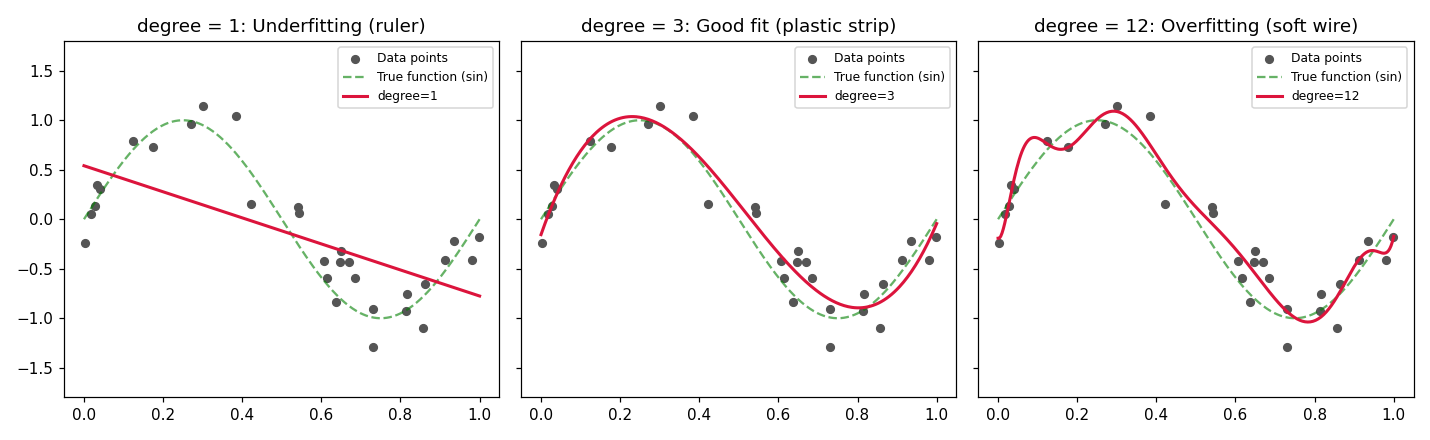


In [73]:
# 合成資料：真實關係是一條曲線，再加上雜訊(用來示範Overfitting)
rng = np.random.RandomState(0) # 固定亂數種子，讓每次執行產生的資料都一樣(可重現)
n = 30 # 只造30個樣本，資料少更容易看到過擬合
x = np.sort(rng.rand(n)) # 產生30個[0,1]隨機數後「由小到大排序」，之後畫線才能依序連起來
y_true = np.cos(1.5 * np.pi * x) # 真實的答案就是一條cos曲線
y_syn = y_true + rng.rand(n) * 0.1 # 加上雜訊模擬真實的觀察值
x = x.reshape(-1, 1) # sklearn要求特徵需要是二維的(樣本數, 特徵數)故轉成(30, 1)

# 切成訓練集和測試集：test_size=0.3 -> 測試集是30%
xtr, xte, ytr2, yte2 = train_test_split(x, y_syn, test_size=0.3, random_state=0)
print(f'合成資料 訓練: {xtr.shape[0]} 筆 / 測試: {xte.shape[0]} 筆')

合成資料 訓練: 21 筆 / 測試: 9 筆


In [74]:
# 匯入工具
from sklearn.preprocessing import PolynomialFeatures # 把特徵擴展成多項式
from sklearn.pipeline import make_pipeline # 把多個步驟串成一個管線，依序自動執行

# 設定要嘗試的多項式次數
degrees = range(1, 25) # degree=1到25，總共有12種複雜度

# 設定兩個空的list來記錄訓練分數和測試分數，之後用畫圖來比較
train_scores, test_scores = [], []

# 對每一個次數degree各訓練一個模型
for d in degrees:
  # 建立管線，先做多項式的轉換，再把轉換後的結果丟到線性迴歸模型
  m = make_pipeline(PolynomialFeatures(d), LinearRegression())
  m.fit(xtr, ytr2) # 模型訓練
  train_scores.append(m.score(xtr, ytr2)) # 對訓練集的R2
  test_scores.append(m.score(xte, yte2)) # 對測試集的R2

# 兩個都印出來看(直接寫變數名只會顯示最後一個)
print(f'train: {[round(s, 3) for s in train_scores]}')
print(f'test : {[round(s, 3) for s in test_scores]}')

# 預期現象：
# d太小：訓練和測試都很低 (欠擬合)
# d適中：兩者都很高且很接近 (最佳)
# d太大：訓練仍很高，但測試不再進步、甚至微幅下滑 (過擬合)

train: [0.635, 0.953, 0.993, 0.998, 0.999, 0.999, 0.999, 0.999, 0.999, 0.999, 0.999, 0.999, 0.999, 0.999, 0.999, 0.999, 0.999, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
test : [-0.278, 0.924, 0.986, 0.995, 0.997, 0.997, 0.995, 0.993, 0.993, 0.993, 0.994, 0.994, 0.995, 0.995, 0.996, 0.996, 0.95, 0.928, 0.899, 0.862, 0.815, 0.757, 0.683, 0.592]


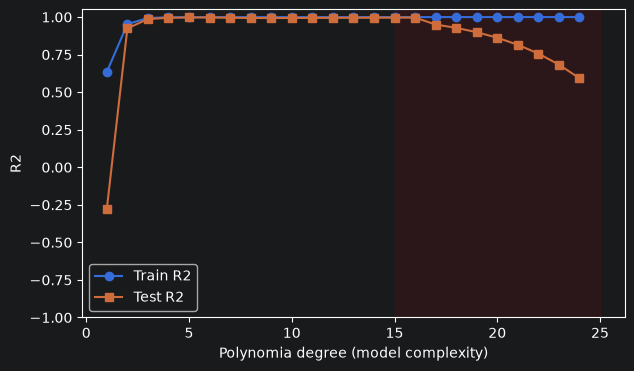

In [75]:
# 把上一個的結果畫成複雜度 vs R2的曲線

plt.figure(figsize=(7, 4))

plt.plot(list(degrees), train_scores, 'o-', label='Train R2') # 'o-'代表圓點+實線
plt.plot(list(degrees), test_scores, 's-', label='Test R2') # 's-'代表方點+實線

# 在次數7~12的範圍塗一塊淡紅色的背景，標示過擬合區
plt.axvspan(15, 25, color='red', alpha=0.08)
plt.ylim(-1, 1.05)
plt.xlabel('Polynomia degree (model complexity)')
plt.ylabel('R2')
plt.legend()
plt.show()

### Bias-Variance 權衡

剛剛那張「複雜度 vs 分數」的圖，可以用兩個詞來解讀：

- **Bias（偏差）**：模型太簡單、抓不到真正的規律 → 圖的**左邊**（低次數），
  train 和 test 分數都低，這就是**欠擬合**。
- **Variance（變異）**：模型太複雜、連雜訊都背起來 → 圖的**右邊**（高次數），
  train 很高但 test 掉下來，這就是**過擬合**。

兩者像一個**蹺蹺板**：複雜度往上調，bias 會下降、但 variance 會上升。
所以最好的模型不在兩端，而在中間，**讓總誤差最低**的那個複雜度。

### 先看一個問題：單次切分的分數，可信嗎？

Bias-Variance 告訴我們：模型太複雜，就會對訓練資料過度敏感，泛化能力變差。
所以我們用測試集的分數來檢查泛化能力，但接下來要問一個更根本的問題：
**測試集算出來的那個分數，本身可不可靠？**

（再提醒一次：這裡談的是**分數**可不可靠，跟前面**模型**的 variance 是不同層次的問題。）

到目前為止我們都是這樣評估模型的：把資料用 `train_test_split` 切成訓練集和測試集，
在訓練集上 `fit`，在測試集上 `score`，得到一個 R²，然後說「這個模型有 0.62 的解釋力」。

但這裡藏著一個容易被忽略的問題：**那條切分線，是隨機畫的。**

`train_test_split` 的 `random_state` 換一個數字，被分到測試集的就是另一批樣本，
算出來的分數也會跟著變。如果 42 這個種子讓你拿到 0.62、7 讓你拿到 0.55、
123 讓你拿到 0.68，那模型真正的實力到底是多少？

跑完你會發現分數上下擺動不小。這代表**單次切分得到的分數，包含了運氣成分**，
你報告的那個數字，一部分是模型的能力，一部分只是「這次剛好切到比較好算的樣本」。

問題還不只這一個：

1. **樣本少的時候更嚴重。** 1000 筆資料切 20% 出來，測試集只有 200 筆，
   幾個離群值就足以讓 R² 差好幾個百分點。金融資料常常就是這種規模
   （一檔股票十年日資料也才 2400 多筆）。

2. **測試集只能用一次。** 測試集的意義是「模擬模型沒看過的未來資料」。
   如果你為了調參數，反覆拿測試集去試 alpha=0.1、1、10 哪個分數高，
   那你其實已經把測試集的資訊「洩漏」進選模決策裡了，它就不再是一個誠實的
   未來模擬，而變成了另一個訓練集。

3. **沒辦法知道模型穩不穩。** 單一個數字只告訴你平均表現，
   卻沒告訴你這個表現有多可靠。一個「時好時壞的 0.6」和一個
   「每次都 0.6」，在實務上是完全不同的兩個模型。

要同時解決這三件事，需要的方法是：**不要只切一次，而是切很多次，
讓每一筆資料都輪流當過一次測試樣本，再看整體的平均與波動。**
這就是交叉驗證（Cross-Validation）在做的事。

---

### K 折交叉驗證怎麼做
把資料平均切成 K 份，每次輪流拿其中 1 份當測試、其餘 K−1 份當訓練，總共跑 K 次。
最後把 K 個分數取平均（順便看波動大小），就得到比單次切分更穩定的評估。
下面用 sklearn 的 `cross_val_score` 實作 5 折。

In [76]:
# cross_val_score：自動跑 K 折交叉驗證，回傳每一折的分數
# KFold：定義如何切成 K 折的規則
from sklearn.model_selection import cross_val_score, KFold

# 設定 5 折交叉驗證
# n_splits = 5，把資料切成 5 份，輪流當驗證集（每一折訓練 4 份，留 1 份作驗證）
# shuffle = True，切分前先把資料打亂，避免原始排序造成誤差
# random_state = 42，固定隨機種子，讓結果可以重現
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# CV 只會在訓練集上面做切分，測試集會到最後一步才會碰
scores = cross_val_score(LinearRegression(), X_train, y_train, cv=cv, scoring='r2')
print(f'每折R2: {scores.round(3)}')
print(f'平均R2: {scores.mean():.3f}')

每折R2: [0.61  0.604 0.635 0.601 0.607]
平均R2: 0.611


## Part 4｜特徵縮放、Pipeline 與評估指標

Part 3 讓我們把「**評估**」做得更可靠（交叉驗證）；
但評估只是量測，模型本身好不好，很多時候取決於**餵進去的資料有沒有處理好**。
這一段就回到資料本身，從最基本的前處理**「特徵縮放」**開始。

### 為什麼要特徵縮放
距離型與正則化模型（KNN、SVM、Ridge/Lasso）對特徵量綱敏感。
若不縮放，數值大的特徵會主導結果（回想 練習 2.1 的 KNN）。
> 樹模型（U4）則**不需要**縮放，這個對比 U4 會再強調。

In [77]:
# 匯入標準化縮放器與 KNN 迴歸模型
from sklearn.preprocessing import StandardScaler # 標準化縮放器：把每個特徵轉成平均0、標準差1
from sklearn.neighbors import KNeighborsRegressor

# 做兩個版本來對照縮放的效果
knn_raw = KNeighborsRegressor() # 版本一：不縮放，直接用原始特徵
# 版本二：用 Pipeline 串起「先標準化，再丟給 KNN」，fit時會自動照順序執行
knn_scaled = make_pipeline(StandardScaler(), KNeighborsRegressor())

# 兩個版本都用同一份訓練資料訓練
kr = knn_raw.fit(X_train, y_train)
ks = knn_scaled.fit(X_train, y_train)

# 在同一份測試集上比 R2
print(f'未經縮放的: {kr.score(X_test, y_test):.4f}')
print(f'縮放的: {ks.score(X_test, y_test):.4f}')

# 解讀本例結果：
#   未縮放 0.15，縮放後跳到 0.67，差距非常大
#   原因：KNN 是靠「特徵空間中的距離」找最近的鄰居來預測，
#         沒縮放時 Population(上千上萬) 會主導距離，收入這種小數值幾乎被忽略
#         標準化後每個特徵地位平等，距離才算得合理，預測就準很多
#   這也解釋了前面 練習 2.1 未縮放 KNN 只有 0.15 的原因

未經縮放的: 0.1463
縮放的: 0.6700


In [78]:
# 這格單獨把 StandardScaler 拆開來看，實際感受它把資料變成什麼樣子
scaler = StandardScaler()
# fit_transform：先從訓練資料學到每個欄位的平均與標準差(fit)，再把資料轉換(transform)
# 轉換公式：(原值 - 平均) / 標準差
x_scaled = scaler.fit_transform(X_train)

# fit_transform 回傳的是 numpy 陣列，會掉欄位名稱，包回 DataFrame 方便觀察
# 小技巧：想保留原欄名可寫 pd.DataFrame(x_scaled, columns=X_train.columns)
x_scaled = pd.DataFrame(x_scaled)
x_scaled.head()

# 解讀本例結果：
#   每個數字都變成「離平均幾個標準差」，所以有正有負、大多落在 -3 ~ 3 之間
#   例如 0 代表剛好等於該欄平均、+1 代表比平均高一個標準差
#   縮放後各欄尺度一致，這正是上一格 KNN 縮放版變準的關鍵

,0,1,2,3,4,5,6,7
0,-0.326196,0.348490,-0.174916,-0.208365,0.768276,0.051376,-1.372811,1.272587
1,-0.035843,1.618118,-0.402835,-0.128530,-0.098901,-0.117362,-0.876696,0.709162
2,0.144701,-1.952710,0.088216,-0.257538,-0.449818,-0.032280,-0.460146,-0.447603
3,-1.017864,0.586545,-0.600015,-0.145156,-0.007434,0.077507,-1.382172,1.232698
4,-0.171488,1.142008,0.349007,0.086624,-0.485877,-0.068832,0.532084,-0.108551


### 常見的線性縮放方法

| 方法 | 公式 | 結果範圍 | 何時用 |
|---|---|---|---|
| **StandardScaler** | $\dfrac{x-\mu}{\sigma}$ | 均值 0、標準差 1（無界） | 預設首選，接近常態時最合理 |
| **MinMaxScaler** | $\dfrac{x-\min}{\max-\min}$ | [0, 1] | 需要固定範圍時，如神經網路輸入、影像 |
| **RobustScaler** | $\dfrac{x-\text{median}}{IQR}$ | 無固定範圍 | **有離群值時**，用中位數與四分位距，不被極端值拉走 |
| **MaxAbsScaler** | $\dfrac{x}{\lvert x \rvert_{\max}}$ | [-1, 1] | 稀疏矩陣（不破壞 0 的位置） |

```python
from sklearn.preprocessing import (StandardScaler, MinMaxScaler,
                                   RobustScaler, MaxAbsScaler)
```

這四個的 API 完全一樣，`fit_transform` / `transform` 可以直接互換，所以只要學會其中一個，其餘三個換個名字就能用。

#### 🎯 綜合練習（本單元 capstone，約 30 分鐘）

**主題：用紅酒的化學成分，預測「脯胺酸（proline）」含量**

sklearn 內建的 Wine 資料集記錄了 178 支紅酒的 13 項化學成分。
本題把其中的 **`proline`（脯胺酸，範圍 278～1680）當作預測目標**，其餘 12 項成分當特徵。

> 💡 **這份資料的關鍵特色**：各特徵的**量綱差異極大**，
> 例如 `magnesium`（鎂，數十～上百）vs `flavanoids`（類黃酮，多在 0～5 之間）。
> 這正是檢驗「標準化到底有沒有用」的好舞台。

**任務**

1. 載入資料並切分（程式碼已提供，直接用）：
```python
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split

w = load_wine(as_frame=True).frame
y = w['proline']                          # 目標：脯胺酸含量
X = w.drop(columns=['proline', 'target'])  # 特徵：其餘 12 項化學成分
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
```

2. 自選 `Ridge` 或 `KNeighborsRegressor`，各建立**兩個版本**：
   - **未縮放版**：直接把模型 `fit(X_train, y_train)`
   - **縮放版**：建立一條 `StandardScaler → 模型` 的 **Pipeline**

3. 兩個版本都在**測試集**上報告 **R² 與 RMSE**。

4. 寫 3 行結論：縮放**有沒有**幫助？幫助有多大？為什麼會這樣？

**提示**
- RMSE 算法：`mean_squared_error(y_test, y_pred) ** 0.5`
- 若選 `KNeighborsRegressor`，縮放的效果會**特別明顯**（想想為什麼，它是靠什麼做預測的？）